# Project Overview

This notebook loads preprocessed data, trains a Logistic Regression model, and generates predictions on the test set. Evaluation is deferred to a later sprint.

# Import Libraries

Import the minimal libraries required for data loading and model training.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split

from src.models.train import (
    train_logistic_regression,
    train_decision_tree,
    train_random_forest,
)
from src.models.predict import predict, predict_probabilities

from src.evaluation.metrics import calculate_metrics
from src.evaluation.reports import generate_classification_report
from src.evaluation.confusion_matrix import plot_confusion_matrix
from src.evaluation.comparison import append_model_results, sort_models

RANDOM_STATE = 42


# Load Processed Data

Load the preprocessed train/test splits produced by the preprocessing notebook.

In [106]:
import sys

workspace_root = Path.cwd()
while not (workspace_root / "src").exists() and workspace_root != workspace_root.parent:
    workspace_root = workspace_root.parent
sys.path.insert(0, str(workspace_root.resolve()))

from src.data.load_data import load_dataset

DATA_DIR = Path("..") / "data" / "processed"
PIPELINE_OUTPUT_DIR = DATA_DIR / "pipeline_outputs"

X_TRAIN_FILE = PIPELINE_OUTPUT_DIR / "X_train.csv"
X_TEST_FILE = PIPELINE_OUTPUT_DIR / "X_test.csv"
Y_TRAIN_FILE = PIPELINE_OUTPUT_DIR / "y_train.csv"
Y_TEST_FILE = PIPELINE_OUTPUT_DIR / "y_test.csv"

if all(path.exists() for path in [X_TRAIN_FILE, X_TEST_FILE, Y_TRAIN_FILE, Y_TEST_FILE]):
    X_train = load_dataset(X_TRAIN_FILE)
    X_test = load_dataset(X_TEST_FILE)
    y_train = load_dataset(Y_TRAIN_FILE).squeeze()
    y_test = load_dataset(Y_TEST_FILE).squeeze()
    print("Loaded pipeline outputs from:", PIPELINE_OUTPUT_DIR)
else:
    raise FileNotFoundError(
        "Expected preprocessed pipeline outputs in data/processed/pipeline_outputs/."
    )

# Drop identifier columns if they remain in the saved feature sets
for id_col in ["customerID", "customer_id", "id"]:
    if id_col in X_train.columns:
        X_train = X_train.drop(columns=[id_col])
    if id_col in X_test.columns:
        X_test = X_test.drop(columns=[id_col])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Loaded pipeline outputs from: ..\data\processed\pipeline_outputs
X_train shape: (5625, 7061)
X_test shape: (1407, 7061)
y_train shape: (5625,)
y_test shape: (1407,)


# Logistic Regression

Train a Logistic Regression classifier on the prepared training data and generate test predictions. Logistic Regression estimates the probability of a binary outcome by fitting a linear decision boundary on the input features. It is commonly used as a baseline classifier because it is stable, interpretable, and fast to train.

In [107]:
# Train logistic regression using reusable trainer
model = train_logistic_regression(X_train, y_train)

# Generate predictions using reusable predict helper
y_pred = predict(model, X_test)

print("Number of training samples:", X_train.shape[0])
print("Number of testing samples:", X_test.shape[0])


d:\cv projects\RetentionAI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Number of training samples: 5625
Number of testing samples: 1407


# Predictions

The trained Logistic Regression model generates predictions for the test set and stores them for later evaluation.

In [108]:
print("Number of predictions:", len(y_pred))
y_pred[:10]

Number of predictions: 1407


array([0, 1, 0, 0, 0, 1, 0, 0, 1, 0])

# Model Evaluation

Calculate standard classification metrics for the test predictions. These metrics measure different aspects of performance and provide more insight than accuracy alone.

In [ ]:
metrics = calculate_metrics(y_test, y_pred)
accuracy = metrics["accuracy"]
precision = metrics["precision"]
recall = metrics["recall"]
f1 = metrics["f1"]

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

print("\nClassification Report:")
print(generate_classification_report(y_test, y_pred))

# Append results to comparison dataframe for later analysis
try:
    comparison_df
except NameError:
    comparison_df = None
comparison_df = append_model_results(comparison_df, "Logistic Regression", metrics)


Accuracy: 0.7946
Precision: 0.6225
Recall: 0.5775
F1 Score: 0.5992

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1033
           1       0.62      0.58      0.60       374

    accuracy                           0.79      1407
   macro avg       0.74      0.73      0.73      1407
weighted avg       0.79      0.79      0.79      1407



# Confusion Matrix

Visualize the confusion matrix and explain the meaning of each result for churn prediction.

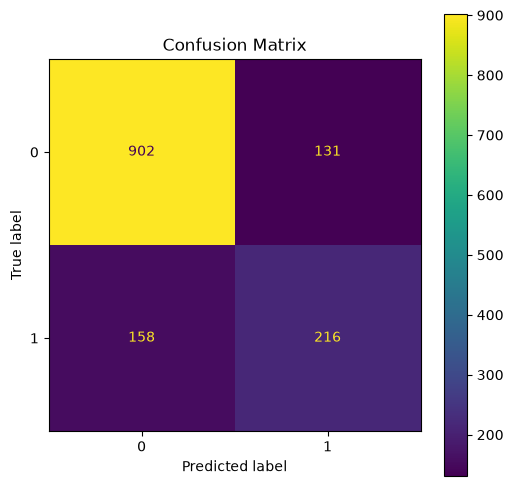

True Positives (TP): 216
True Negatives (TN): 902
False Positives (FP): 131
False Negatives (FN): 158


In [ ]:
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

# Display confusion matrix using the reusable plotting helper
plot_confusion_matrix(model, X_test, y_test)

print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")


- True Positives (TP): churn customers correctly identified as churn.
- True Negatives (TN): retained customers correctly identified as not churn.
- False Positives (FP): retained customers incorrectly labeled as churn.
- False Negatives (FN): churn customers incorrectly labeled as not churn.

In churn prediction, false negatives are especially costly because they represent customers who churned without being flagged for retention efforts. False positives also matter because they can waste retention resources on customers who would have stayed.

# Decision Tree Classifier

Train a Decision Tree classifier on the same train/test split and compare its behavior to Logistic Regression. Decision Trees partition the feature space using sequential binary splits, making decisions based on feature thresholds.

One advantage of Decision Trees is that they can model nonlinear relationships and interactions without feature engineering. One disadvantage is that they can overfit the training data, especially when grown deep, which makes them less stable than Logistic Regression.

Decision Tree Accuracy: 0.7448
Decision Tree Precision: 0.5225
Decision Tree Recall: 0.4652
Decision Tree F1 Score: 0.4922

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83      1033
           1       0.52      0.47      0.49       374

    accuracy                           0.74      1407
   macro avg       0.67      0.66      0.66      1407
weighted avg       0.74      0.74      0.74      1407



<Figure size 600x600 with 0 Axes>

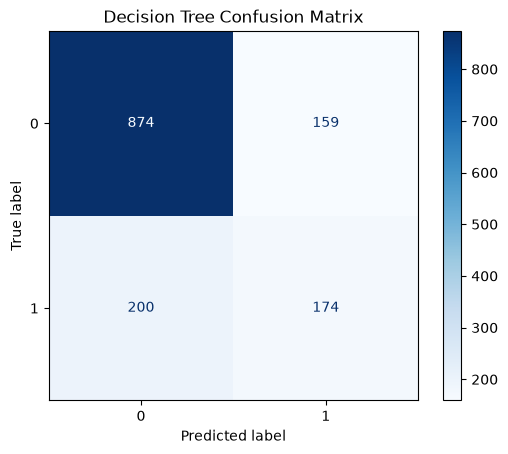

In [ ]:
# Train decision tree using reusable trainer
clf = train_decision_tree(X_train, y_train)

# Predict and evaluate
y_pred_tree = predict(clf, X_test)

metrics_tree = calculate_metrics(y_test, y_pred_tree)
accuracy_tree = metrics_tree["accuracy"]
precision_tree = metrics_tree["precision"]
recall_tree = metrics_tree["recall"]
f1_tree = metrics_tree["f1"]

print(f"Decision Tree Accuracy: {accuracy_tree:.4f}")
print(f"Decision Tree Precision: {precision_tree:.4f}")
print(f"Decision Tree Recall: {recall_tree:.4f}")
print(f"Decision Tree F1 Score: {f1_tree:.4f}")

print("\nDecision Tree Classification Report:")
print(generate_classification_report(y_test, y_pred_tree))

# Append results to comparison dataframe
try:
    comparison_df
except NameError:
    comparison_df = None
comparison_df = append_model_results(comparison_df, "Decision Tree", metrics_tree)

cm_tree = confusion_matrix(y_test, y_pred_tree)

# Use plotting helper to display the confusion matrix
plot_confusion_matrix(clf, X_test, y_test)


# Random Forest Classifier

Train a Random Forest classifier on the same train/test split and compare its performance to the single Decision Tree. Random Forest builds many decision trees and aggregates their predictions to reduce variance and improve generalization.

Random Forest Accuracy: 0.7946
Random Forest Precision: 0.6604
Random Forest Recall: 0.4679
Random Forest F1 Score: 0.5477

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.47      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



<Figure size 600x600 with 0 Axes>

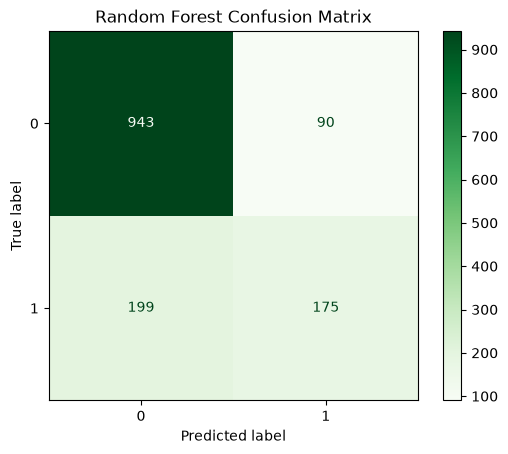

In [ ]:
# Train random forest using reusable trainer
rf_model = train_random_forest(X_train, y_train)

# Predict and evaluate
y_pred_rf = predict(rf_model, X_test)

metrics_rf = calculate_metrics(y_test, y_pred_rf)
accuracy_rf = metrics_rf["accuracy"]
precision_rf = metrics_rf["precision"]
recall_rf = metrics_rf["recall"]
f1_rf = metrics_rf["f1"]

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")
print(f"Random Forest F1 Score: {f1_rf:.4f}")

print("\nRandom Forest Classification Report:")
print(generate_classification_report(y_test, y_pred_rf))

# Append results to comparison dataframe
try:
    comparison_df
except NameError:
    comparison_df = None
comparison_df = append_model_results(comparison_df, "Random Forest", metrics_rf)

cm_rf = confusion_matrix(y_test, y_pred_rf)

# Display confusion matrix using the reusable plotting helper
plot_confusion_matrix(rf_model, X_test, y_test)


Random Forest usually performs better than a single Decision Tree because it averages the predictions of many trees, which reduces overfitting and improves robustness to noise. Ensemble learning combines multiple models to make a final prediction, so the strengths of individual estimators are pooled and the impact of any single weak model is reduced.